Processing code for KPFM histograms with both single and multi-gaussian fitting and a stretched exponential fitting scatter plots for any time series. 


Inputs: 
- .txt files of time series (in chronological order - either from image numbers or numbered 0 to x (however many you have))
- rows - number of rows to skip, currently set to three
- Image time - reset based on image time (include space for time taken to move to next image (i.e. 85s to take, 5s to move back to start line means time = 90s))

Outputs:

- Can do single or multigaussian fitting --> waterfall plot 
- Gives time constant metrics using stretched exponential (only for illumination curves)
- Full plotting with time series and spread, light off time adjusted based on experiment. 



In [8]:
#Imports
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import scipy.stats as stats 
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import tkinter as tk
from tkinter import filedialog
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm
from matplotlib.ticker import MaxNLocator
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from tqdm import tqdm

Using Tkinter to open popup for folder path of histograms and for saving all plots to .jpeg files (can be changed if needed but other sections may need formatting) 

In [9]:
#Input directory and file saving function 
root = tk.Tk()
root.withdraw()
print("If pop up box not seen minimise spyder and select folder wanted for analysis")
folder_path = filedialog.askdirectory(title='Select input folder')
save_path = filedialog.askdirectory(title='Select Folder to Save Plot')

    
def save_plot_with_folder_dialog(fig, default_filename='plot.jpeg'):
    root = tk.Tk()
    root.withdraw()  # Hide the root window

    folder_path = filedialog.askdirectory(title='Select Folder to Save Plot')
    if not folder_path:
        print("Save cancelled.")
        return

    full_path = os.path.join(folder_path, default_filename)
    fig.savefig(full_path)
    print(f"Plot saved to: {full_path}")
    
def save_plot_to_folder(fig, folder_path, filename='plot.jpeg'):
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)  # Create the folder if it doesn't exist
    
    full_path = os.path.join(folder_path, filename)
    fig.tight_layout()
    fig.savefig(full_path, dpi=600, bbox_inches='tight')
    print(f"Plot saved to: {full_path}")

If pop up box not seen minimise spyder and select folder wanted for analysis


In [10]:
#Starting timer for runtime 
import time
start_time = time.time()

Using this section to set colourbars for histogram fitting. Change c1 and c2 as min and max colours (current is colourblind friendly). 

In [11]:
#Colourmap formatting
# Change c1 and c2 based on the min and max colours to be chosen 

def hex_to_RGB(hex_str):
    
    """ #FFFFFF -> [255,255,255]"""
    
    return [int(hex_str[i:i+2], 16) for i in range(1,6,2)]

def get_color_gradient(c1, c2, n):

    assert n > 1
    c1_rgb = np.array(hex_to_RGB(c1))/255
    c2_rgb = np.array(hex_to_RGB(c2))/255
    mix_pcts = [x/(n-1) for x in range(n)]
    rgb_colors = [((1-mix)*c1_rgb + (mix*c2_rgb)) for mix in mix_pcts]
    return ["#" + "".join([format(int(round(val*255)), "02x") for val in item]) for item in rgb_colors]


colors=[]
c1='#1A85FF'#deep blue
c2='#D41159' # deep pink


GB_U_color = "#5CBBFF"
GI_U_color = "#003357"
GB_P_color = "#D69AAB"
GI_P_color = "#8D1730"

Fitting for a single gaussian (not as accurate but sets a baseline for any changes that occur in the multi-gaussian fitting). 

In [12]:
#Single Gaussian Fitting function: 
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Gaussian fitting function using data from a dataset (i.e. from each individual file) 
def fit_gaussian_from_dataset(x_data, y_data):
    """
    Fit a Gaussian curve to the provided dataset (x_data, y_data).
    Args:
    - x_data: Array-like, x values of the data
    - y_data: Array-like, y values of the data
    
    Returns:
    - A_fit: Amplitude of the fitted Gaussian
    - mu_fit: Mean (center) of the fitted Gaussian
    - sigma_fit: Standard deviation (width) of the fitted Gaussian
    - popt: Optimal parameters from curve fitting
    - pcov: Covariance matrix
    """
    # Initial guess for the parameters [A, mu, sigma]
    initial_guess = [max(y_data), np.mean(x_data), np.std(x_data)]

    try:
        # Fit the Gaussian curve to the data
        popt, pcov = curve_fit(gaussian, x_data, y_data, p0=initial_guess, maxfev=100000000)
        
        # Extract fitted parameters
        A_fit, mu_fit, sigma_fit = popt
        min_raw=np.min(x_data)
        mean_raw=np.mean(x_data)
        max_raw=np.max(x_data)
        # Print the fitted parameters for feedback
        #print(f"Fitted parameters:\nAmplitude: {A_fit}\nMean: {mu_fit}\nSigma: {sigma_fit}")
        #print(f"Raw data parameters are:\n Min = {min_raw}\n Mean = {mean_raw}\n Max = {max_raw}")
       
        # Return the fitted parameters and covariance matrix
        return A_fit, mu_fit, sigma_fit, popt, pcov, min_raw, mean_raw, max_raw

    except Exception as e:
        print(f"Error fitting Gaussian: {e}")
        return None, None, None, None, None

#Fitting for single gaussian
def fit_gaussian_from_files(file_directory, rows, image_time):
    min_scatter=[]
    mean_scatter=[]
    max_scatter=[]
    time_scatter=[]
    gaussian_scatter=[]
    t=-int(image_time)

    dpi_setting = 600
    figsize_x, figsize_y = (1147/dpi_setting), (770/dpi_setting)
    tick_length = 6
    legend_font = 12
    base_font_size = 12
    scatter_size = 18
    line_width = 3
    fig, ax = plt.subplots(1,1, sharey = True, figsize = (2.79,1.87))
    plt.rcParams.update({'font.size': base_font_size})
    ## this outputs a 1x1 subplot - change if you want more/less rows or columns ##
    ax = plt.gca()
    ax.tick_params(direction='in', length=tick_length)
    ax.tick_params(axis='both', labelsize=base_font_size)
    ax.margins (0.5,0.5)
    plt.xlabel("SPV (V)", size = base_font_size)
    ax.autoscale(enable=None, axis="x", tight=True)
    plt.ylabel("Distribution (V$^{-1}$)", fontsize=base_font_size)
    files=sorted([f for f in os.listdir(file_directory) if f.endswith('.txt')])
    n_files=len(files)
    colors=get_color_gradient(c1,c2,n_files)
    # Limit number of ticks
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on x-axis
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on y-axis
    # Loop through files in the specified directory
 #   for filename in os.listdir(file_directory):
    for idx, filename in enumerate(tqdm(files, desc="Processing files")):
        file_path = os.path.join(file_directory, filename)
        #print(f"\nProcessing file: {filename}")
        t += image_time
        time_scatter.append(t)

        with open(file_path, 'r', encoding='utf-8', errors='replace') as f:
            data = np.loadtxt(f, skiprows=rows)

        x_data = data[:, 0]
        y_data = data[:, 1]
            
            # Fit the Gaussian curve to this dataset
        A, mu, sigma, popt, pcov, min_raw, mean_raw, max_raw = fit_gaussian_from_dataset(x_data, y_data)
        min_scatter.append(min_raw)
        mean_scatter.append(mean_raw)
        max_scatter.append(max_raw)
        y_fit=gaussian(x_data,*popt)
        #for finding peak centre for fitted gaussian
        peak_index=np.argmax(y_fit)
        x_fit_max=x_data[peak_index]
        gaussian_scatter.append(x_fit_max)
        #Uncomment for debugging: 
        #print(f"Min:{min_scatter}\n Mean: {mean_scatter}\n Max: {max_scatter}")
        #print(time_scatter)
        # If fitting was successful, plot the result
        if A is not None:
            
            plt.scatter(x_data, y_data, label=f"{t}s", color=colors[idx], s=scatter_size)
            plt.plot(x_data, y_fit, label=f"_nolegend_", color=colors[idx], linewidth=line_width)
            plt.title(f"Single Gaussian Fitting", size=base_font_size)
            plt.xlabel("SPV (V)", size=20)
            plt.ylabel("Distribution $V^{-1}$", size=base_font_size)
            plt.autoscale()
            #plt.legend()
                
    print("All gaussians processed. Congrats!")
    # Add the colorbar after plotting
    cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)
    norm = mcolors.Normalize(vmin=np.min(time_scatter), vmax=np.max(time_scatter))
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.tight_layout()
    cbar = fig.colorbar(sm, ax=ax, orientation='vertical')
    cbar.set_label('Time (s)', size=base_font_size)
    cbar.ax.tick_params(labelsize=base_font_size)
    plt.autoscale(enable=True, axis='y', tight=False)
    #Comment out if no file saving required
    fig=plt.gcf()
    save_plot_to_folder(fig, save_path, filename='SingleGaussian_Histogram.jpeg')
    return min_scatter, mean_scatter, max_scatter, time_scatter, gaussian_scatter
    plt.show() #Keep after saving figure due to errors. 

Multi-gaussian fitting function. Change estimate_guess_from_data --> wid =0.001 (based on current data) so change according to histogram width tolerance (either 0.1, 0.01 or 0.001). Runs through all files within folder. If initial time index is not 0 change this in the image time within function)

In [13]:
#Fitting for multi-gaussian
#Adjust peak width tolerance accordingly

# Function to model N Gaussians
def multi_gaussian(x, *params):
    n = len(params) // 3
    y = np.zeros_like(x)
    for i in range(n):
        amp = params[i * 3]
        cen = params[i * 3 + 1]
        wid = params[i * 3 + 2]
        y += amp * np.exp(-((x - cen) ** 2) / (2 * wid ** 2))
    return y


# Auto-generate initial guess based on data
def estimate_guess_from_data(x, y, prominence=0.1, distance=10):
    y_smooth = gaussian_filter1d(y, sigma=2)
    peaks, _ = find_peaks(y_smooth, prominence=prominence, distance=distance)
    
    # Sort peaks by height (amplitude) and limit to top 2
    if len(peaks) > 2:
        sorted_indices = np.argsort(properties['prominences'])[::-1][:2]
        peaks = peaks[sorted_indices]

    guess = []
    for i in peaks:
        amp = y[i]
        cen = x[i]
        wid = 0.001 # Adjust based on data
        guess += [amp, cen, wid]
    
    return guess, len(peaks)


#Multi-gaussian fitting for all files within file directory
def multi_gaussian_folder(file_directory, rows, image_time):
    min_scatter=[]
    mean_scatter=[]
    max_scatter=[]
    time_scatter=[]
    multigaussian_min = []
    multigaussian_max = []
    multigaussian_peak=[]
    t=-int(image_time)
    #Plotting parameters
    dpi_setting = 600
    figsize_x, figsize_y = (2227/dpi_setting), (1498/dpi_setting)
    tick_length = 6
    #legend_font = 12
    base_font_size = 12
    scatter_size = 6
    line_width = 1.5
    fig, ax = plt.subplots(1, 1, sharey=True, figsize=(figsize_x, figsize_y))
    plt.rcParams.update({'font.size': base_font_size})
    ax = plt.gca()
    ax.tick_params(direction='in', length=tick_length)
    ax.tick_params(axis='both')
    ax.margins (0.5,0.5)
    plt.xlabel("SPV (V)")
    ax.autoscale(enable=None, axis="x", tight=True)
    plt.ylabel("Distribution (V$^{-1}$)")
    files=sorted([f for f in os.listdir(file_directory) if f.endswith('.txt')])
    n_files=len(files)
    colors=get_color_gradient(c1,c2,n_files)
    # Limit number of ticks
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on x-axis
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on y-axis
    results = []
    for idx, filename in enumerate(tqdm(files, desc="Processing files")):
    
        file_path = os.path.join(file_directory, filename)
        #print(f"\nProcessing file: {filename}") #Use if you want each individual file processed
        t += image_time
        time_scatter.append(t)

        with open(file_path, 'r', encoding='utf-8', errors='replace') as f:
            data = np.loadtxt(f, skiprows=rows)

        x_data = data[:, 0]
        y_data = data[:, 1]
            
        # Estimate initial guess and peak count
        initial_guess, n_peaks = estimate_guess_from_data(x_data, y_data)
        min_raw=np.min(x_data)
        max_raw=np.max(x_data)
        mean_raw=np.mean(x_data)
        min_scatter.append(min_raw)
        mean_scatter.append(mean_raw)
        max_scatter.append(max_raw)
        #x_fit= np.linspace(np.min(x_data), np.max(x_data), 1000000)
        popt, pcov = curve_fit(multi_gaussian, x_data, y_data, p0=initial_guess, maxfev=100000000)
        # print('='*50)
        # print(popt)
        # print('='*50)
        # print(pcov)
        # print('='*50)
        perr = np.sqrt(np.diag(pcov))
        y_fit=multi_gaussian(x_data,*popt)
        peak_index_max=np.argmax(y_fit)
        x_peak_centre=x_data[peak_index_max]
        multigaussian_peak.append(x_peak_centre)
        # print(x_peak_centre)
        # print('='*50)

        #For finding min and max *i.e. either side of the peaks. 
        # Extract Gaussian parameters
        gaussians = []
        for i in range(len(popt) // 3):
            amp = popt[i*3]
            cen = popt[i*3+1]
            wid = abs(popt[i*3+2])
            gaussians.append({'amp': amp, 'cen': cen, 'wid': wid})

        # Identify the highest peak
        #highest = max(gaussians, key=lambda g: g['amp'])
        highest = gaussians[np.argmax([g['amp'] for g in gaussians])]
        # FWHM = 2.355 * sigma
        fwhm = 2.355 * highest['wid']
        x_left = highest['cen'] - fwhm / 2
        x_right = highest['cen'] + fwhm / 2

        # Store in lists for output
        multigaussian_min.append(x_left)
        multigaussian_max.append(x_right)
        # Optional: print for debugging
        #print(f"  Highest Peak at x = {highest['cen']:.4f}")
        #print(f"  FWHM = {fwhm:.4f} → Bounds: [{x_left:.4f}, {x_right:.4f}]")
        if n_peaks is not None:
   
            # Plot
                #Plotting parameters
            plt.scatter(x_data, y_data, label=f"{t}s",color=colors[idx], s=scatter_size)
            plt.plot(x_data, multi_gaussian(x_data, *popt), label=f"_nolegend_", color=colors[idx],linewidth=line_width)
            plt.title(f"Multi-Gaussian Fitting")
            plt.xlabel("SPV(V)")
            plt.ylabel("Distribution $V^{-1}$")
            plt.autoscale()
        #plt.legend()
        #plt.tight_layout()
            #plt.show()
    print("All multi gaussians processed. Congrats!")

    # Add the colorbar after plotting
    cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)
    norm = mcolors.Normalize(vmin=np.min(time_scatter), vmax=np.max(time_scatter))
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.tight_layout()
    cbar = fig.colorbar(sm, ax=ax, orientation='vertical')
    cbar.set_label('Time (s)')
    cbar.ax.tick_params(size=tick_length, labelsize = base_font_size)
    plt.autoscale(enable=True, axis='y', tight=False)
    #Uncomment for file saving
    #fig=plt.gcf()
    #save_plot_to_folder(fig,save_path,filename='MultiGaussian_Histogram.jpeg')
    return mean_scatter, time_scatter, multigaussian_min, multigaussian_max, multigaussian_peak
    plt.show()    

Set image time and number of rows to skip within .txt files. Call x and y data for scatter plots from either single or multi-gaussian and raw or fitted data. 

X:/ramadan_group/Group Members/Rehmat Goodwin/Lab Data/Processed Data/25_03_12_FACs_HK_Batch1/1 - KPFM/Time Series/Main Temporal SPV/Passivated/White Light/LightOn


Processing files: 100%|██████████| 100/100 [00:44<00:00,  2.25it/s]


All multi gaussians processed. Congrats!


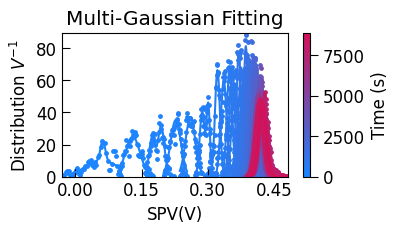

In [14]:
#Outputting single and multi gaussian plots:
#Uncomment folder_path input or copy into code directly if tkinter not working
#Can uncomment inputs if this varies between experiments
#folder_path=input("What is the folder path?")
#folder_path=r"X:\ramadan_group\Group Members\Rehmat Goodwin\Lab Data\Processed Data\25_03_12_FACs_HK_Batch1\250312_RG0087_KPFM\Histograms\CPD copy\LightOn" # Replace with your folder path
#rows=int(input("How many rows should be skipped?"))
rows=3
#image_time=int(input("What was the image time?(in seconds)"))
image_time= 90 #seconds
print(folder_path)
#min,mean,max,time, gaussian_scatter=fit_gaussian_from_files(folder_path,rows,image_time)

mean_scatter, time_scatter, multigaussian_min, multigaussian_max, multigaussian_peak= multi_gaussian_folder(folder_path, rows, image_time)

x_data=time_scatter #Change according to whether using single or multi gaussian
y_data=multigaussian_peak #can change this dependant on whether you want single or multi-gaussian 
#y_data = gaussian_scatter # Good check for if there is strange behaviour from the multi-gaussian fit. 


Stretched exponential fitting function. If errors are found use streteched exponential without the with statement

Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/Lab Data/Processed Data/25_03_12_FACs_HK_Batch1/1 - KPFM/Time Series\ScatterWithSpread_Unpassivated.jpeg


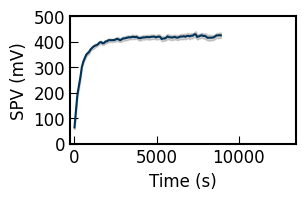

In [15]:
#Plotting scatter without fitting
#uncomment to check scatter for multiple different scatter plots. 

dpi_setting = 600
figsize_x, figsize_y = (1933/dpi_setting), (1300/dpi_setting)
tick_length = 6
legend_font = 12
base_font_size = 12
scatter_size = 18
line_width = 1.5


multigaussian_peak_new=[round(x*1000,4) if not np.isnan(x) else np.nan for x in multigaussian_peak]
multigaussian_min_new=[round(x*1000,4) if not np.isnan(x) else np.nan for x in multigaussian_min]
multigaussian_max_new=[round(x*1000,4) if not np.isnan(x) else np.nan for x in multigaussian_max]


plt.figure(figsize=(figsize_x, figsize_y))
ax = plt.gca()
plt.rcParams.update({'font.size': base_font_size})
ax.tick_params(axis='both',direction='in', length=tick_length)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(line_width)
plt.xlabel("Time (s)")
plt.ylabel("SPV (mV)")
ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
plt.plot(time_scatter,multigaussian_peak_new,'-', label = 'Average SPV', color=GI_U_color, linewidth=line_width)
plt.plot(time_scatter, multigaussian_min_new, color='#6F6F6F', linewidth=0.0001)
plt.plot(time_scatter, multigaussian_max_new, color='#6F6F6F', linewidth=0.0001)
plt.fill_between(time_scatter, multigaussian_min_new, multigaussian_max_new, color='#6F6F6F',
                 alpha=0.3)
if np.max(time_scatter)> 9050:
    plt.vlines(x=image_time*96,
           ymin=0, 
           ymax=500,
           linestyle = '--',
           linewidth=1,
          color = 'black',
#          label = 'Light Off'
              )
    plt.vlines(x=0,
           ymin=0, 
           ymax=500,
           linestyle = '--',
           linewidth=1,
          color = 'black',
#          label = 'Light Off'
              )
    plt.hlines(y=0,
           xmin=0, 
           xmax=time_scatter[-1],
           linestyle = '--',
           linewidth=2,
          color = 'black',
#          label = 'Light Off'
              )
    #recovery = [image_time*100, image_time*150]
    #recovery = [image_time*96, image_time*150]
    #plt.fill_between(recovery, 0, 500, color=GI_U_color, alpha=0.2)
#else:
#    print('Only single region of time series. No light off line needed')
##For white light (all)
ax.set_ylim(0,500)
ax.set_xlim(-image_time*3,image_time*150)
##For 365nm
#ax.set_ylim(-100,200)
#ax.set_xlim(-image_time*3,image_time*60)
##For 850nm
#ax.set_ylim(-60,60)
#ax.set_xlim(-image_time*3,image_time*90)
#uncomment for saving figures
fig=plt.gcf()
plt.tight_layout()
save_plot_to_folder(fig, save_path,filename='ScatterWithSpread_Unpassivated.jpeg')
plt.show()


Adjusted exponential to check time constant and fitting if stretched exponential doesn't work. 

In [16]:
# Adjusted exponential fit to check: 

def adjusted_exponential(t, A, tau, const):
    return A*(1-np.exp(-(t/tau)))+const
def d_adjusted_exponential(t, A, tau):
    return (A/tau)*np.exp(-t/tau)


Things for Ben: 
- Change to fit this with derivative (add parameter to make selecting point on curve flexible)
- Adjust any other bits needed for this! 
- Also check whether error calculation for shaded plots below is fine? - taken from FWHM of largest peak only from above multi-gaussian fitting


Completing exponential fitting and plotting. Values output for guesses onto the plot in a textbox. 
can omit running this step if just aiming to output gaussian's. 

Constant initial = 63.38


Fitting 2: 100%|██████████| 1000000/1000000 [00:02<00:00, 388895.02it/s]


Fitted Parameters:
A = 341.80, error = 4.556977341233053
tau = 468.38, error = 10.299698231639423
constant=75.18, error = 4.576318604612055
time constant=2009.40
SPV_sat=416.98069028983707, error = 6.458229978827782


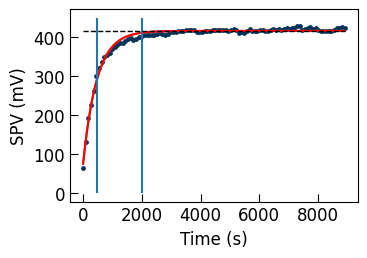

In [ ]:
#Running through to try adjusted exponential
#This can be made into a function if needed
#Adjusted exponential fitting: 
#try: 
# Fit the data using curve_fit
#defining initial guesses: 

A_initial = np.max(multigaussian_peak_new)#If data is positive then this should be max, if negative then it is min
tau_initial= np.median(x_data) #Can also try max/2 or mean to see if this works
const_initial=np.min(multigaussian_peak_new)
print(f"Constant initial = {const_initial:.2f}")
initial_guess = [A_initial,tau_initial, const_initial]  # Initial guess for A, tau, const
params, covariance = curve_fit(adjusted_exponential, x_data, multigaussian_peak_new, p0=initial_guess, maxfev=1000000)
#print(params[0], params[1], params[2])
#k_initial = 1/tau_initial
cutoff = 0.01
# Extract the parameters (A, tau, beta)
A, tau, const = params

# Generate 1000 new x values between the minimum and maximum of original x_data
x_fit= np.linspace(np.min(x_data), np.max(x_data), 1000000)
y_fit1= np.array([adjusted_exponential(np.array([x]), *params)[0] for x in tqdm(x_fit, desc="Fitting")])
dy_fit = np.array([d_adjusted_exponential(np.array([x]), A, tau)[0] for x in tqdm(x_fit, desc="Fitting 2")])
time_cst = x_fit[np.where(dy_fit < cutoff)[0][0]]
perr=np.sqrt(np.diag(covariance))

print("Fitted Parameters:")
print(f"A = {A:.2f}, error = {perr[0]}")
print(f"tau = {tau:.2f}, error = {perr[1]}")
print(f"constant={const:.2f}, error = {perr[2]}")
print(f"time constant={time_cst:.2f}")
SPV_sat_err = np.sqrt(perr[0]**2+perr[2]**2)

print(f"SPV_sat={A+const}, error = {SPV_sat_err}")
#start_SPV_sat = np.where(x_fit==tau)
#for x in x_fit: 
#    if int(x)==int(tau): 
#        start_SPV_sat = x
#    else: 
#        print ("Error finding index")
#end_SPV_sat = len(x_fit)
#max_fit=np.max(y_fit)
#SPV_sat = np.mean(y_fit[start_SPV_sat:end_SPV_sat])
#print(f"SPV_max = {max_fit}")
#print(f"SPV_sat = {SPV_sat}")

# Plotting data:
dpi_setting = 600
figsize_x, figsize_y = (2227/dpi_setting), (1498/dpi_setting)
tick_length = 6
legend_font = 12
base_font_size = 12
scatter_size = 6
line_width = 1.5
plt.figure(figsize=(figsize_x, figsize_y))
plt.rcParams.update({'font.size': base_font_size})
ax = plt.gca()
ax.tick_params(direction='in', length=tick_length)
ax.tick_params(axis='both')
#ax.margins (0.3,0.3)
plt.xlabel("Time (s)")
plt.ylabel("SPV (mV)")
# Limit number of ticks

ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on x-axis
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on y-axis
#plt.plot(x_data, y_data, label='Data', color='#8D1730', linewidth=2)
plt.scatter(x_data, multigaussian_peak_new, label='Data', color=GI_U_color, s=scatter_size)
plt.plot(x_fit, y_fit1, label='Fit', color='#6F6F6F', linewidth=line_width)
plt.vlines(x=tau, ymin=0, ymax=450)
plt.vlines(x=time_cst, ymin=0, ymax=450)
plt.hlines(y=A+const, xmin=0, xmax=x_fit[-1], color='black', linestyle='--', linewidth=1)
plt.autoscale(enable=True, axis='y', tight=False)
#ax.set_ylim(-0.05,0.05)
#uncomment for saving figures
#    fig=plt.gcf()
#    save_plot_to_folder(fig, save_path,filename='AdjustedExpFitScatter.jpeg')
#Automatically adjust the y-axis
    
#except Exception as e: 
#    print("Fitting has failed. See errors or just come back later.")
#    print(e.args)

#Fitted scatter plots
plt.show()

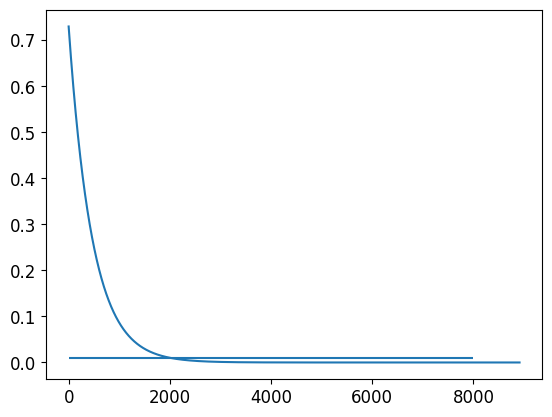

In [18]:
plt.plot(x_fit,dy_fit)
plt.hlines(y=0.01, xmin=0, xmax=8000)

In [19]:
print(max(multigaussian_peak_new))
print(A)


429.3191
341.7961472570897


Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/Lab Data/Processed Data/25_03_12_FACs_HK_Batch1/1 - KPFM/Time Series\ScatterWithSpread_Unpassivated.jpeg


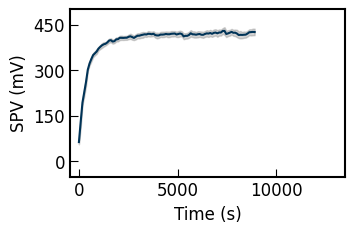

In [20]:
#Plotting spread with any relevant lines: 
plt.figure(figsize=(figsize_x, figsize_y))
ax = plt.gca()
plt.rcParams.update({'font.size': base_font_size})
ax.tick_params(axis='both',direction='in', length=tick_length)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(line_width)
plt.xlabel("Time (s)")
plt.ylabel("SPV (mV)")
ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
plt.plot(time_scatter,multigaussian_peak_new,'-', label = 'Average SPV', color=GI_U_color, linewidth=line_width)
plt.plot(time_scatter, multigaussian_min_new, color='#6F6F6F', linewidth=0.0001)
plt.plot(time_scatter, multigaussian_max_new, color='#6F6F6F', linewidth=0.0001)
plt.fill_between(time_scatter, multigaussian_min_new, multigaussian_max_new, color='#6F6F6F',
                 alpha=0.3)
if np.max(time_scatter)> 9050:
    plt.vlines(x=image_time*96,
           ymin=-50, 
           ymax=500,
           linestyle = '--',
           linewidth=1,
          color = 'black',
#          label = 'Light Off'
              )
    plt.vlines(x=0,
           ymin=-50, 
           ymax=500,
           linestyle = '--',
           linewidth=1,
          color = 'black',
#          label = 'Light Off'
              )
    
    #recovery = [image_time*100, image_time*150]
    recovery = [image_time*100, image_time*150]
    #plt.fill_between(recovery, 0, 500, color=GI_U_color, alpha=0.2)
#else:
#    print('Only single region of time series. No light off line needed')
##For white light (all)
ax.set_ylim(-50,500)
ax.set_xlim(-image_time*5,image_time*150)

##For 365nm
#ax.set_ylim(-100,200)
#ax.set_xlim(-image_time*3,image_time*60)
##For 850nm
#ax.set_ylim(-60,60)
#ax.set_xlim(-image_time*3,image_time*90)
#uncomment for saving figures
fig=plt.gcf()
plt.tight_layout()
save_plot_to_folder(fig, save_path,filename='ScatterWithSpread_Unpassivated.jpeg')
plt.show()

In [21]:
#Runtime check: 
import time
end_time = time.time()
elapsed = end_time-start_time
print(f'Total runtime is {elapsed:.3f} seconds')

Total runtime is 53.966 seconds


In [22]:
t_cst_unpass = 2701.52
tau_unpass = 842.03
t_cst_pass = 2009.40
tau_pass = 468.38

time_change=t_cst_unpass/t_cst_pass
tau_change = 1-tau_pass/tau_unpass
print("tau change", tau_change)
print("timeconst change", time_change)

tau change 0.4437490350700094
timeconst change 1.344441126704489
